In [1]:
import numpy as np
import pandas as pd
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from matplotlib.colors import LogNorm


import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import SmoothBivariateSpline  # or griddata / RBFInterpolator

# from cosipy import UnBinnedData, BinnedData


In [2]:
bkg_ = [20, 20, 20, 20, 20, 20, 10, 10, 10, 10, 10, 10,  1, 1, 1,1,1,1]
eta_ = [0.1,0.3,0.5, 0.1,0.3,0.5, 0.1,0.3,0.5, 0.1,0.3,0.5,0.1,0.3,0.5, 0.1,0.3,0.5] #
softer_ = [False, False, False, True, True, True, False, False, False, True, True, True,
          False, False, False, True, True, True, False, False, False, True, True, True] 

f_ = [
      '/RemadeNov2025/November2025_COSI_Eta0.1_bkg20.00.csv',
      '/RemadeNov2025/November2025_COSI_Eta0.3_bkg20.00.csv',
      '/RemadeNov2025/November2025_COSI_Eta0.5_bkg20.00.csv',

      '/RemadeNov2025/November2025_COSI_Eta0.1_bkg20.00softer0.5.csv',
      '/RemadeNov2025/November2025_COSI_Eta0.3_bkg20.00softer0.5.csv',
      '/RemadeNov2025/November2025_COSI_Eta0.5_bkg20.00softer0.5.csv',

      '/RemadeNov2025/November2025_COSI_Eta0.1_bkg10.00.csv',
      '/RemadeNov2025/November2025_COSI_Eta0.3_bkg10.00.csv',
      '/RemadeNov2025/November2025_COSI_Eta0.5_bkg10.00.csv',

      '/RemadeNov2025/November2025_COSI_Eta0.1_bkg10.00softer0.5.csv',
      '/RemadeNov2025/November2025_COSI_Eta0.3_bkg10.00softer0.5.csv',
      '/RemadeNov2025/November2025_COSI_Eta0.5_bkg10.00softer0.5.csv',

      '/RemadeNov2025/November2025_COSI_Eta0.1_bkg1.00.csv',
      '/RemadeNov2025/November2025_COSI_Eta0.3_bkg1.00.csv',
      '/RemadeNov2025/November2025_COSI_Eta0.5_bkg1.00.csv',

      '/RemadeNov2025/November2025_COSI_Eta0.1_bkg1.00softer0.5.csv',
      '/RemadeNov2025/November2025_COSI_Eta0.3_bkg1.00softer0.5.csv',
      '/RemadeNov2025/November2025_COSI_Eta0.5_bkg1.00softer0.5.csv',
      ]

bkg_long = [20, 20, 10, 10,  1, 1]
softer_long = [False, True, False, True, False, True] 

f_long = [
      './FlareCounting/source_mdp_summary_bkg_20_rate.csv',
      './FlareCounting/source_mdp_summary_bkg_20_rate_softer.csv',
    
      './FlareCounting/source_mdp_summary_bkg_10_rate.csv',
      './FlareCounting/source_mdp_summary_bkg_10_rate_softer.csv',
    
      './FlareCounting/source_mdp_summary_bkg_1_rate.csv',
      './FlareCounting/source_mdp_summary_bkg_1_rate_softer.csv',
      ]


# COSI MDP plots

In [19]:
import math

# wrap the code below in a function to plot the MDP colormap for FSRQ only given a dataframe df2_clean
def plot_mdp_colormap_fsrq(dataframe, dataframe_long, plot_eta_value, plot_bkg_value, save_fig=False, fig_name='mdp_colormap_fsrq.png'):
    ############
    # FSRQ only
    ############

    CMAP = 'cubehelix_r'
    #CMAP='RdBu'
    
    # f = '/Users/mnegro/MyDocuments/_FERMI/LCR/LCRanalyses/figs/Aug2025_COSI_eta0.5_bkg0.10_Softer+0.5.csv'
    # df2 = pd.read_csv(f, sep=',', index_col=False, header=0)
    fsrq = dataframe[dataframe['Class'] == 'FSRQ']
    # consider only MDP<=100
    fsrq = fsrq[fsrq['MDP99_(%)'] <= 100]
    #consider only durations <8 weeks
    fsrq = fsrq[fsrq['Duration_(s)'] <= 8*7*24*60*60]
    print('Number of FSRQ flares with MDP<=100 and duration <=8 weeks:', len(fsrq))
    dur = fsrq['Duration_(s)']/60/60/24/7  # convert to weeks
    dur = dur // 1

    # consider only MDP<=100
    fsrq_long = dataframe_long[dataframe_long['MDP99_(%)'] <= 100]
    #consider only durations <8 weeks
    fsrq_long = fsrq_long[fsrq_long['Duration_(s)'] <= 8*7*24*60*60]
    print('Number of FSRQ flares with MDP<=100 and duration <=8 weeks:', len(fsrq_long))
    dur_long = fsrq_long['Duration_(s)']/60/60/24/7  # convert to weeks
    dur_long = dur_long // 1

    # print the nuique values of durations
    print('Unique durations (weeks):', np.unique(dur))
    dmin, dmax = 0.95, dur.max()
    fmin, fmax = fsrq['Average_Photon_Flux_(ph/cm2/s)_(0.2-5_MeV)'].min(), fsrq['Average_Photon_Flux_(ph/cm2/s)_(0.2-5_MeV)'].max()
    print('Duration range (weeks):', dmin, dmax)
    print('Flux range (ph/cm2/s):', fmin, fmax)

    # print the nuique values of durations
    print('Unique durations (weeks):', np.unique(dur))
    dmin_long, dmax_long = 0.95, dur.max()
    fmin_long, fmax_long = fsrq_long['Average_Photon_Flux_(ph/cm2/s)_(0.2-5_MeV)'].min(), fsrq_long['Average_Photon_Flux_(ph/cm2/s)_(0.2-5_MeV)'].max()
    print('Duration range (weeks):', dmin_long, dmax_long)
    print('Flux range (ph/cm2/s):', fmin_long, fmax_long)

    #count how many flares below 50% MDP
    n_below_mdp50 = len(fsrq[fsrq['MDP99_(%)'] < 50])
    print('Number of FSRQ flares below MDP=50%:', n_below_mdp50)
    # count how many flares below 20% MDP
    n_below_mdp20 = len(fsrq[fsrq['MDP99_(%)'] < 20])   
    print('Number of FSRQ flares below MDP=20%:', n_below_mdp20)

    # scale the duration values into a reasonable marker size range
    sizes = 50 + 800 * (dur - dur.min()) / (dur.max() - dur.min())

    #print lowest MDP in the sample
    print('Lowest MDP in the sample:', np.min(dataframe['MDP99_(%)']))
    # to what duration and flux corresponds?
    idx_min_mdp = np.argmin(dataframe['MDP99_(%)'])
    print('Duration (weeks):', dataframe['Duration_(s)'].values[idx_min_mdp]/60/60/24/7)
    print('Flux (ph/cm2/s):', dataframe['Average_Photon_Flux_(ph/cm2/s)_(0.2-5_MeV)'].values[idx_min_mdp])

    #count how many flares below 50% MDP
    n_below_mdp50_long = len(fsrq_long[fsrq_long['MDP99_(%)'] < 50])
    print('Number of FSRQ flares below MDP=50%:', n_below_mdp50_long)
    # count how many flares below 20% MDP
    n_below_mdp20_long = len(fsrq_long[fsrq_long['MDP99_(%)'] < 20])   
    print('Number of FSRQ flares below MDP=20%:', n_below_mdp20_long)

    # scale the duration values into a reasonable marker size range
    sizes_long = 50 + 800 * (dur_long - dur_long.min()) / (dur_long.max() - dur_long.min())

    #print lowest MDP in the sample
    print('Lowest MDP in the sample:', np.min(dataframe_long['MDP99_(%)']))
    # to what duration and flux corresponds?
    idx_min_mdp_long = np.argmin(dataframe_long['MDP99_(%)'])
    print('Duration (weeks):', dataframe_long['Duration_(s)'].values[idx_min_mdp_long]/60/60/24/7)
    print('Flux (ph/cm2/s):', dataframe_long['Average_Photon_Flux_(ph/cm2/s)_(0.2-5_MeV)'].values[idx_min_mdp_long])


    # data
    x = fsrq['Duration_(s)'].to_numpy() /60/60/24/7
    y = fsrq['Average_Photon_Flux_(ph/cm2/s)_(0.2-5_MeV)'].to_numpy()
    z = fsrq['MDP99_(%)'].to_numpy()

    # data
    x_long = fsrq_long['Duration_(s)'].to_numpy() /60/60/24/7
    y_long = fsrq_long['Average_Photon_Flux_(ph/cm2/s)_(0.2-5_MeV)'].to_numpy()
    z_long = fsrq_long['MDP99_(%)'].to_numpy()

    # log-spaced grid that matches your log axes
    nx, ny = 300, 300
    # dmin, dmax = x.min(), x.max()
    # fmin, fmax = y.min(), y.max()
    gx = np.logspace(np.log10(np.min([dmin,dmin_long])), np.log10(10), nx)
    gy = np.logspace(np.log10(np.min([fmin,fmin_long])-0.2*np.min([fmin,fmin_long])), np.log10(np.max([fmax,fmax_long])+0.4*np.max([fmax,fmax_long])), ny)
    GX, GY = np.meshgrid(gx, gy, indexing='xy')  # GX.shape == GY.shape == (ny, nx)

    # ---- interpolation (example: smoothed spline in log–log space) ----
    xu, yu = np.log10(x_long), np.log10(y_long)
    s = 1.0 * len(z_long) * np.var(z_long)                 # tune smoothing as needed
    spline = SmoothBivariateSpline(xu, yu, z_long, s=s, kx=3, ky=3)

    # Evaluate on grid; keep shape (ny, nx)
    Z = spline.ev(np.log10(GX).ravel(), np.log10(GY).ravel()).reshape(GX.shape)

    # ---- plot without transposes ----
    fig, ax = plt.subplots(figsize=(8,6))
    pcm = ax.pcolormesh(GX, GY, Z, shading='auto', cmap=CMAP, vmin=0, vmax=100, alpha=0.7)
    plt.scatter(
        fsrq['Duration_(s)']/60/60/24/7 //1,
        fsrq['Average_Photon_Flux_(ph/cm2/s)_(0.2-5_MeV)'],
        c=fsrq['MDP99_(%)'],
        cmap=CMAP,
        marker='o',
        s=sizes*3,            # size varies with duration
        alpha=0.8,
        edgecolor='k',
        label = 'BB-Selected',
    )

    plt.scatter(
        fsrq_long['Duration_(s)']/60/60/24/7 //1,
        fsrq_long['Average_Photon_Flux_(ph/cm2/s)_(0.2-5_MeV)'],
        c=fsrq_long['MDP99_(%)'],
        cmap=CMAP,
        marker='D',
        s=sizes_long*3,            # size varies with duration
        alpha=0.8,
        edgecolor='dodgerblue',
        label = 'Manually-Selected',
    )

    # scattter of th epoint with MDP>50% with black filled color but 0.5 alpha
    fsrq_above50 = fsrq[fsrq['MDP99_(%)'] >= 50]
    #no fill color but hatched edge
    plt.scatter(
        fsrq_above50['Duration_(s)']/60/60/24/7 //1,
        fsrq_above50['Average_Photon_Flux_(ph/cm2/s)_(0.2-5_MeV)'],
        facecolors='none',
        edgecolors='k',
        hatch='///',
        c='none',
        marker='o',
        s=sizes[fsrq['MDP99_(%)'] >= 50]*3,            # size varies with duration
        alpha=0.5,
        #edgecolor='k',
    )

    # scattter of th epoint with MDP>50% with black filled color but 0.5 alpha
    fsrq_above50_long = fsrq_long[fsrq_long['MDP99_(%)'] >= 50]
    #no fill color but hatched edge
    plt.scatter(
        fsrq_above50_long['Duration_(s)']/60/60/24/7 //1,
        fsrq_above50_long['Average_Photon_Flux_(ph/cm2/s)_(0.2-5_MeV)'],
        facecolors='none',
        edgecolors='dodgerblue',
        hatch='///',
        c='none',
        marker='D',
        s=sizes_long[fsrq_long['MDP99_(%)'] >= 50]*3,            # size varies with duration
        alpha=0.5,
        #edgecolor='k',
    )

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(0.95, 8.5)
    ax.set_ylim(np.log10(dmin_long), np.log10(np.max([fmax,fmax_long])+0.4*np.max([fmax,fmax_long])))
    ax.set_xlabel('Flare Duration (weeks)', fontsize=17)
    ax.set_ylabel('0.2–5 MeV Photon Flux (ph/cm²/s)', fontsize=17)
    ax.set_title(r'$\eta=%.1f$, $R_{bkg}=%.1f$ ct/s, Softer spectrum ($\gamma_{1}+0.5$)' % (plot_eta_value, plot_bkg_value), fontsize=17)

    #change format of x-axis tick labels to 1,2,3...
    from matplotlib.ticker import FormatStrFormatter
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))
    ax.xaxis.set_minor_formatter(FormatStrFormatter('%.0f'))
    ax.tick_params(axis='x', which = 'both', labelsize=16)
    ax.tick_params(axis='y', which = 'both', labelsize=17)
    
    # make label of colorbar
    cbar = fig.colorbar(pcm, ax=ax,label=r'$\mathrm{MDP_{99{\%}}}$')
    #cbar = plt.colorbar(label=r'$\mathrm{MDP_{99_{\%}}}$')
    cbar.ax.tick_params(labelsize=16)
    cbar.ax.yaxis.label.set_size(17)
    cbar.ax.xaxis.label.set_size(17)
    #add a line at the MDP=50% and MDP=20%
    cs = ax.contour(GX, GY, Z, levels=[20, 50], colors=['black', 'black'], linestyles=['--', '--'], linewidths=2)
    # add labels to the contour lines
    fmt = {50: r'$\mathrm{MDP_{99{\%}}}=50\%$', 20: r'$\mathrm{MDP_{99{\%}}}=20\%$'}
    ax.clabel(cs, inline=True, fontsize=11, fmt=fmt, manual=[(1.1, 9e-4), (1.3, 0.9e-2)])
    plt.tight_layout()
    # plt.savefig(title_fig, dpi=200)


    if save_fig:
        plt.savefig(fig_name, dpi=300)

def plot_cumulative_fluence_flare_count(dataframe, plot_eta, plot_bkg, save_fig=False, fig_name='cumulative_fluence_flare_count.png'):
    print('Total number of sources in the sample:', len(dataframe))
    bll = dataframe[dataframe['Class'] == 'BLL']
    fsrq = dataframe[dataframe['Class'] == 'FSRQ']
    bcu = dataframe[dataframe['Class'] == 'BCU']
    bll_tot = len(bll)
    fsrq_tot = len(fsrq)
    bcu_tot = len(bcu)
    print('Total number of flares from BCU in the sample:', bcu_tot)
    print('from unique sources:', len(bcu['Name'].unique()))
    print('Total number of flares from BLL in the sample:', bll_tot)
    print('from unique sources:', len(bll['Name'].unique()))    
    print('Total number of flares from FSRQ in the sample:', fsrq_tot)
    print('from unique sources:', len(fsrq['Name'].unique()))

    fluence_th_array = np.logspace(np.log10(1e-3), np.log10(1e5), 1000)
    bll_flares_above_th = []
    fsrq_flares_above_th = []
    bcu_flares_above_th = []
    for th in fluence_th_array:
        bll_flares_above_th.append(len(bll[bll['Photon_Fluence_(ph/cm2)_(0.2-5_MeV)'] > th]))
        fsrq_flares_above_th.append(len(fsrq[fsrq['Photon_Fluence_(ph/cm2)_(0.2-5_MeV)'] > th]))
        bcu_flares_above_th.append(len(bcu[bcu['Photon_Fluence_(ph/cm2)_(0.2-5_MeV)'] > th]))
    bll_flares_above_th = np.array(bll_flares_above_th)
    fsrq_flares_above_th = np.array(fsrq_flares_above_th)
    bcu_flares_above_th = np.array(bcu_flares_above_th)
    #figure of the 1/cumulative of the fluence for BLL, FSRQ and BCU


    plt.figure(figsize=(8,6))
    fig,ax=plt.subplots(figsize=(8,6))
    plt.title(r'$\eta=%.1f$, $R_{bkg}=%.1f$ ct/s, Softer spectrum ($\gamma_{1}+0.5$)' %(plot_eta, plot_bkg), size=15)
    plt.step(fluence_th_array, bll_flares_above_th/17, where='post', label='BL Lac', color='blue', linewidth=4)
    plt.step(fluence_th_array, fsrq_flares_above_th/17, where='post', label='FSRQ', color='red', linewidth=4)
    #plt.step(fluence_th_array, bcu_flares_above_th/17, where='post', label='BCU', color='0.6', linewidth=4, linestyle='--')
    # mark 1 flare per year
    plt.hlines(1, fluence_th_array[0], fluence_th_array[-1], linestyle='--', color='silver')
    plt.annotate('1 flare per year', xy=(fluence_th_array[10], 1.1), color='silver', size=12)

    plt.vlines(3270, 0.06, 220, linestyle=':', color='0.5')
    print('min fluence for MDP<50% (softer)', th)
    plt.vlines(19534, 0.06, 220, linestyle='-.', color='0.5')
    print('min fluence for MDP<20% (softer)', lowest_fluences_mdp20[i])
    #Bkg=%.2f - $\eta$=%.1f - Softer'%(bkg, eta)
    plt.annotate(r'Min fluence for $\mathrm{MDP_{99{\%}}}$<50%',
            xy=(3270*1.1, 6), color='0.5', size=10, rotation=90)
    plt.annotate(r'Min fluence for $\mathrm{MDP_{99{\%}}}$<20%',
            xy=(19534*1.1, 5), color='0.5', size=10, rotation=90)

    ##Show the lowest fluence for MDP=0.5 and MDP=0.3
    #for i, th in enumerate(lowest_fluences_mdp50):
    #    bkg = bkg_[i]
    #    if bkg == 1.00:
    #        continue
    #    eta = eta_[i]
    #    if eta != 0.5:
    #        continue
    #    softer = softer_[i]
    #    print(bkg, softer, th)
    #    if softer:
    #        print('Softer spectrum case')
    #        plt.vlines(th, 0.06, 220, linestyle=':', color='0.5')
    #        print('min fluence for MDP<50% (softer)', th)
    #        plt.vlines(lowest_fluences_mdp20[i], 0.06, 220, linestyle='-.', color='0.5')
    #        print('min fluence for MDP<20% (softer)', lowest_fluences_mdp20[i])
    #        #Bkg=%.2f - $\eta$=%.1f - Softer'%(bkg, eta)
    #        plt.annotate('Min fluence for MDP<50%',
    #                xy=(th*1.1, 8), color='0.5', size=10, rotation=90)
    #        plt.annotate('Min fluence for MDP<20%',
    #                xy=(lowest_fluences_mdp20[i]*1.1, 8), color='0.5', size=10, rotation=90)
    #    else:
    #        print('Standard spectrum case')
    #        continue
    #        # plt.annotate('Bkg=%.2f - $\eta$=%.1f'%(bkg, eta), 
    #        #          xy=(th*1.1, 15), color='0.5', size=10, rotation=90)
    # plt.step(np.sort(df2_bcu['Fluence (ph/cm2)']), np.cumsum(bcu['Fluence (ph/cm2)'])[::-1], where='post', label='BCU', color='0.6')
    plt.xscale('log')
    plt.yscale('log')  
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15) 
    plt.ylim(0.06, 220)
    plt.xlim(5e-4, 3e5)
    plt.xlabel(r'Fluence (ph/cm$^2$)', size=18)  
    plt.ylabel(r'N$_{flares}$(>Fluence)/year', size=18) 
    plt.legend(fontsize=15, loc=3)

    if save_fig:
        plt.savefig(fig_name, bbox_inches='tight')
        

<!-- Index(['Unnamed: 0', 'Name', 'Class', 'Photon Flux (ph/cm2/s)',
       'Fluence (ph/cm2)', 'Photon Count', 'Background Counts', 'Duration (s)',
       'Duration (weeks)', 'Fraction of Observation Time', 'MDP99',
       'Start Time (MJD)', 'Start Time (s)', 'Asymmetry'],
      dtype='object') -->

In [20]:
#select the plot case:

f = './RemadeNov2025/November2025_COSI_Eta0.3_bkg1.00softer0.5.csv'
f_long = './FlareCounting/source_flares_softer_bkg_1_rate.csv'
plot_eta = 0.3
plot_bkg = 1.0

filter_list=['4FGL J0116.0-1136','4FGL J0200.6-6637','4FGL J0224.9+1843','4FGL J0304.5+3349','4FGL J0347.7-3616',
'4FGL J0427.3-3900','4FGL J0450.3-4419','4FGL J0617.6-4028','4FGL J0746.4+2546','4FGL J0805.4+6147','4FGL J0943.7+6137',
'4FGL J1043.2+2408','4FGL J1200.7+2008','4FGL J1659.7-3131','4FGL J1747.6-5308','4FGL J1824.5+0107','4FGL J1912.1-0803',
'4FGL J2040.5-1705','4FGL J2120.6-1254','4FGL J2148.6+0652','4FGL J2149.7+1917','4FGL J2207.6+0053','4FGL J2358.0-4601',
'4FGL J0024.7+0349','4FGL J0239.7+0415','4FGL J0904.6+5200','4FGL J1118.2-0415','4FGL J1205.7-2635','4FGL J1324.9+4748',
'4FGL J1445.9-1626','4FGL J1559.9+2319','4FGL J1650.3-5045','4FGL J1941.3-6210','4FGL J0805.4+6147','4FGL J1153.4+4931',
'4FGL J0010.6+2043','4FGL J0222.0-1616','4FGL J0228.0-3026','4FGL J0312.8+0134','4FGL J0358.9+6004','4FGL J0824.7+5552',
'4FGL J1031.6+6019','4FGL J1209.8+1810','4FGL J1446.7+1719','4FGL J1635.6+3628','4FGL J1647.5+4950','4FGL J1716.1+6836',
'4FGL J1724.9+7654','4FGL J1808.1-5013','4FGL J2256.0-2740','4FGL J0405.6-1308','4FGL J0336.4+3224',
'4FGL J1337.6-1257','4FGL J1924.8-2914',
'4FGL J0433.0+0522','4FGL J0522.9-3628','4FGL J0324.8+3412',
'4FGL J0034.0-4116','4FGL J0035.8+6131','4FGL J0137.9+5814','4FGL J0152.2+3714','4FGL J0156.5+3914','4FGL J0342.2+3858',
'4FGL J0353.0+5654','4FGL J0401.7+2112','4FGL J0407.5+0741','4FGL J0453.3+2843','4FGL J0455.7-4617','4FGL J0512.8+4041',
'4FGL J0635.6-7518','4FGL J0638.7+5658','4FGL J0647.7-6058','4FGL J0713.0+5738','4FGL J0723.5+2900','4FGL J0747.3-3310',
'4FGL J0806.5+4503','4FGL J0836.5-2026','4FGL J0911.0-5047','4FGL J0923.5+3852','4FGL J1001.1+2911','4FGL J1015.6+5553',
'4FGL J1016.0+0512','4FGL J1018.1+1905','4FGL J1045.8-2928','4FGL J1136.2+3407','4FGL J1158.5+4824','4FGL J1225.6-7313',
'4FGL J1238.5-1201','4FGL J1322.2+0842','4FGL J1440.0-1530','4FGL J1454.4-3744','4FGL J1513.4-3231','4FGL J1516.9+1934',
'4FGL J1656.0+2047','4FGL J1753.6-5014','4FGL J1808.2+3500','4FGL J1834.7-5858','4FGL J1912.0+1612','4FGL J1917.7-6930',
'4FGL J1942.1+4011','4FGL J2130.4-4241','4FGL J2143.1-3929','4FGL J2146.4-1528','4FGL J2219.2-0342','4FGL J2359.2-3134',
'4FGL J1632.8-1048','4FGL J1148.5+2629','4FGL J0319.8+4130','4FGL J1829.5+4845']

filter_list_long=['4FGL J0116.0-1136','4FGL J0200.6-6637','4FGL J0224.9+1843','4FGL J0304.5+3349','4FGL J0347.7-3616',
'4FGL J0427.3-3900','4FGL J0450.3-4419','4FGL J0617.6-4028','4FGL J0746.4+2546','4FGL J0805.4+6147','4FGL J0943.7+6137',
'4FGL J1043.2+2408','4FGL J1200.7+2008','4FGL J1659.7-3131','4FGL J1747.6-5308','4FGL J1824.5+0107','4FGL J1912.1-0803',
'4FGL J2040.5-1705','4FGL J2120.6-1254','4FGL J2148.6+0652','4FGL J2149.7+1917','4FGL J2207.6+0053','4FGL J2358.0-4601',
'4FGL J0024.7+0349','4FGL J0239.7+0415','4FGL J0904.6+5200','4FGL J1118.2-0415','4FGL J1205.7-2635','4FGL J1324.9+4748',
'4FGL J1445.9-1626','4FGL J1559.9+2319','4FGL J1650.3-5045','4FGL J1941.3-6210','4FGL J0805.4+6147',
'4FGL J0010.6+2043','4FGL J0222.0-1616','4FGL J0228.0-3026','4FGL J0312.8+0134','4FGL J0358.9+6004','4FGL J0824.7+5552',
'4FGL J1031.6+6019','4FGL J1209.8+1810','4FGL J1446.7+1719','4FGL J1635.6+3628','4FGL J1647.5+4950','4FGL J1716.1+6836',
'4FGL J1724.9+7654','4FGL J1808.1-5013','4FGL J2256.0-2740','4FGL J0405.6-1308','4FGL J0336.4+3224',
'4FGL J1337.6-1257','4FGL J1924.8-2914',
'4FGL J0433.0+0522','4FGL J0522.9-3628','4FGL J0324.8+3412',
'4FGL J0034.0-4116','4FGL J0035.8+6131','4FGL J0137.9+5814','4FGL J0152.2+3714','4FGL J0156.5+3914','4FGL J0342.2+3858',
'4FGL J0353.0+5654','4FGL J0401.7+2112','4FGL J0407.5+0741','4FGL J0453.3+2843','4FGL J0455.7-4617','4FGL J0512.8+4041',
'4FGL J0635.6-7518','4FGL J0638.7+5658','4FGL J0647.7-6058','4FGL J0713.0+5738','4FGL J0723.5+2900','4FGL J0747.3-3310',
'4FGL J0806.5+4503','4FGL J0836.5-2026','4FGL J0911.0-5047','4FGL J0923.5+3852','4FGL J1001.1+2911','4FGL J1015.6+5553',
'4FGL J1016.0+0512','4FGL J1018.1+1905','4FGL J1045.8-2928','4FGL J1136.2+3407','4FGL J1158.5+4824','4FGL J1225.6-7313',
'4FGL J1238.5-1201','4FGL J1322.2+0842','4FGL J1440.0-1530','4FGL J1454.4-3744','4FGL J1513.4-3231','4FGL J1516.9+1934',
'4FGL J1656.0+2047','4FGL J1753.6-5014','4FGL J1808.2+3500','4FGL J1834.7-5858','4FGL J1912.0+1612','4FGL J1917.7-6930',
'4FGL J1942.1+4011','4FGL J2130.4-4241','4FGL J2143.1-3929','4FGL J2146.4-1528','4FGL J2219.2-0342','4FGL J2359.2-3134',
'4FGL J1632.8-1048','4FGL J1148.5+2629','4FGL J0319.8+4130','4FGL J1829.5+4845']

df2 = pd.read_csv(f, sep=',', index_col=False, header=0)

df2 = df2[~df2['Name'].isin(filter_list)]
df2 = df2[df2['Duration_(s)'] <= 8*7*24*60*60]

# remove rows that have nan or -3333 in any of the relevant columns
relevant_columns = ['Average_Photon_Flux_(ph/cm2/s)_(0.2-5_MeV)',  'Photon_Fluence_(ph/cm2)_(0.2-5_MeV)', 'MDP99_(%)']
df2_clean = df2.dropna(subset=relevant_columns)
for col in relevant_columns:
    df2_clean = df2_clean[df2_clean[col] != -3333]  
print('After cleaning, number of flares:', len(df2_clean))  

#how many unique sources in the cleaned dataframe
print('Number of unique sources in the cleaned dataframe:', len(df2_clean['Name'].unique()))

df2_long = pd.read_csv(f_long, sep=',', index_col=False, header=0)

df2_long = df2_long[~df2_long['Name'].isin(filter_list_long)]
df2_long = df2_long[df2_long['Duration_(s)'] <= 8*7*24*60*60]

# remove rows that have nan or -3333 in any of the relevant columns
relevant_columns = ['Average_Photon_Flux_(ph/cm2/s)_(0.2-5_MeV)',  'Photon_Fluence_(ph/cm2)_(0.2-5_MeV)', 'MDP99_(%)']
df2_long_clean = df2_long.dropna(subset=relevant_columns)
for col in relevant_columns:
    df2_long_clean = df2_long_clean[df2_long_clean[col] != -3333]  
print('After cleaning, number of flares:', len(df2_clean))  

#how many unique sources in the cleaned dataframe
print('Number of unique sources in the cleaned dataframe:', len(df2_long_clean['Name'].unique()))


After cleaning, number of flares: 1311
Number of unique sources in the cleaned dataframe: 326
After cleaning, number of flares: 1311
Number of unique sources in the cleaned dataframe: 25


Number of FSRQ flares with MDP<=100 and duration <=8 weeks: 80
Number of FSRQ flares with MDP<=100 and duration <=8 weeks: 80
Unique durations (weeks): [1. 2. 3. 4. 5. 6. 7. 8.]
Duration range (weeks): 0.95 8.0
Flux range (ph/cm2/s): 0.0008966755917559 0.0075004756018222
Unique durations (weeks): [1. 2. 3. 4. 5. 6. 7. 8.]
Duration range (weeks): 0.95 8.0
Flux range (ph/cm2/s): 0.0011155957685639 0.0185643000775999
Number of FSRQ flares below MDP=50%: 37
Number of FSRQ flares below MDP=20%: 1
Lowest MDP in the sample: 19.80572831088953
Duration (weeks): 8.0
Flux (ph/cm2/s): 0.0040373615310997
Number of FSRQ flares below MDP=50%: 50
Number of FSRQ flares below MDP=20%: 14
Lowest MDP in the sample: 5.147378886584486
Duration (weeks): 7.0
Flux (ph/cm2/s): 0.0183210478234671


/tmp/ipykernel_59567/716156634.py:168: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(np.log10(dmin_long), np.log10(np.max([fmax,fmax_long])+0.4*np.max([fmax,fmax_long])))


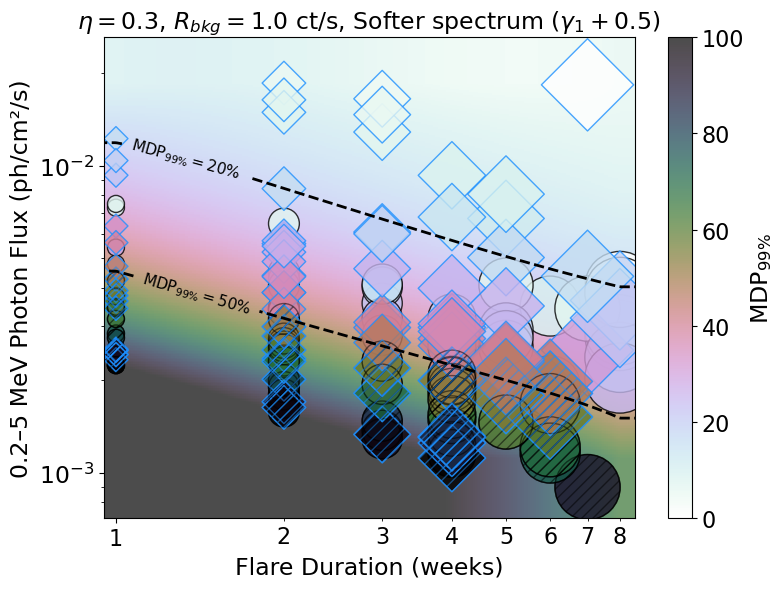

In [21]:
#plot_cumulative_fluence_flare_count(df2_clean, plot_eta, plot_bkg, save_fig=False, fig_name='./Final_csvs/RemadeFeb2026CSV/Cumulative_fluence_flare_count_eta{}_bkg{}_BLL_FSRQ_only_new_8week_cut.pdf'.format(plot_eta, plot_bkg))

plot_mdp_colormap_fsrq(df2_clean, df2_long_clean, 0.3, 1.0, save_fig=False, fig_name='./Final_csvs/RemadeFeb2026CSV/mdp_colormap_fsrq_eta{}_bkg{}_new_8week_cut_with_long.png'.format(plot_eta, plot_bkg))
